# KL expressibility vs Haar fidelity distribution

Porownanie expressibility dwoch ansatzow (`model_odra` i `model_simulator`) przez
$D_{KL}(P_{ansatz}(F)\|P_{Haar}(F))$, gdzie
$F = |\langle \psi(\theta_a) | \psi(\theta_b) \rangle|^2$,
a parametry sa losowane z $\theta \sim U[0, 2\pi]$.

### Publication-oriented configuration

- **Depths:** Training experiments in the paper use nominal depths \(L\in\{2,4,6\}\). Including `8` in `DEPTHS` extends the diagnostic (useful to see whether \(D_{\mathrm{KL}}\) has largely saturated); use `[2, 4, 6]` only if the manuscript should not discuss \(L=8\).
- **Monte Carlo:** The reported \(D_{\mathrm{KL}}\) depends on binned empirical frequencies; larger `N_FIDELITY_SAMPLES_PER_DEPTH` reduces Monte Carlo noise. Target \(\gtrsim 2\times 10^{5}\) for table values when feasible; increase further for final camera-ready numbers if runtime permits.
- **Histogram:** `N_BINS` balances resolution (especially near \(F\to 1\)) against sparsity in bins; keep `EPS` identical to the LaTeX. Optionally re-run the depth sweep at \(B\in\{100,200\}\) and check that the qualitative ansatz ordering is stable.
- **Convergence plot:** `DEPTH_FOR_CONVERGENCE` defaults to **6** (largest training depth in the paper). The sample-size grid includes `N_FIDELITY_SAMPLES_PER_DEPTH` so the right-hand side matches the table. Set to `2` where \(D_{\mathrm{KL}}\) is largest, or to `max(DEPTHS)` for the deepest circuit.


In [9]:
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from tqdm import tqdm as tqdm_std
import torch
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.quantum_info import Statevector

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

N_QUBITS = 5
DIM = 2 ** N_QUBITS
# Depths: paper uses L in {2,4,6}; 8 is optional exploratory (see markdown above).
DEPTHS = [2, 4, 6, 8]
# MC sample count per (depth, ansatz); raise for lower variance in reported D_KL (e.g. 500_000 final).
N_FIDELITY_SAMPLES_PER_DEPTH = 200_000
N_BINS = 150
EPS = 1e-12  # must match LaTeX / numerical_stability in manuscript
# Convergence curve depth: 6 aligns with max training depth; use 2 or max(DEPTHS) as alternatives.
DEPTH_FOR_CONVERGENCE = 6
USE_TQDM = True
SHOW_INNER_PROGRESS = True

# In Jupyter / VS Code notebook: tqdm.notebook uses ipywidgets (HTML bar updates in place).
# Fallback: plain tqdm writes to stderr; many frontends show that as many lines.
tqdm_notebook = None
try:
    import ipywidgets as _ipyw  # noqa: F401 — needed for tqdm.notebook (IProgress)

    from IPython import get_ipython

    if get_ipython() is not None:
        from tqdm.notebook import tqdm as tqdm_notebook
except Exception:
    pass


def tqdm_maybe(iterable, **kwargs):
    if not USE_TQDM:
        return iterable
    kwargs.setdefault('leave', False)
    kwargs.setdefault('mininterval', 1.0)
    kwargs.setdefault('dynamic_ncols', True)
    return tqdm_std(iterable, **kwargs)


def tqdm_inner(iterable, **kwargs):
    if not USE_TQDM:
        return iterable
    kwargs.setdefault('leave', False)
    if tqdm_notebook is not None:
        return tqdm_notebook(iterable, **kwargs)
    kwargs.setdefault('mininterval', 1.0)
    kwargs.setdefault('dynamic_ncols', True)
    return tqdm_std(iterable, **kwargs)

## Ansatz definitions 

In [10]:
def ansatz_trimmed_reverse_q0_param_count(n_qubits: int, depth: int) -> int:
    """Weights when only the last macro-layer uses the q0-incident reverse trim."""
    m = depth // 2
    if m == 0:
        return 0
    full = 4 * n_qubits
    last = 3 * n_qubits + 2
    return (m - 1) * full + last


def odra_ansatz(n_qubits: int, depth: int) -> QuantumCircuit:
    # Full reverse (4n) on all macro-layers except the last; there trim reverse to q0 edges only (3n+2).
    n_macro = depth // 2
    theta = ParameterVector("theta", ansatz_trimmed_reverse_q0_param_count(n_qubits, depth))
    qc = QuantumCircuit(n_qubits)
    p = 0

    for j in range(n_macro):
        last_layer = j == n_macro - 1

        for i in range(n_qubits):
            qc.ry(theta[p + i], i)
        p += n_qubits

        for i in range(n_qubits):
            control = i
            target = (i + 1) % n_qubits
            qc.rz(theta[p + i], target)
            qc.cz(control, target)
        p += n_qubits

        for i in range(n_qubits):
            qc.rx(theta[p + i], i)
        p += n_qubits

        if last_layer:
            for k in range(2):
                i = k
                control = i
                target = (i - 1) % n_qubits
                qc.ry(theta[p + k], target)
                qc.cz(control, target)
            p += 2
        else:
            for i in range(n_qubits):
                control = i
                target = (i - 1) % n_qubits
                qc.ry(theta[p + i], target)
                qc.cz(control, target)
            p += n_qubits

    assert p == len(theta)
    return qc


def simulator_ansatz(n_qubits: int, depth: int) -> QuantumCircuit:
    n_macro = depth // 2
    theta = ParameterVector("theta", ansatz_trimmed_reverse_q0_param_count(n_qubits, depth))
    qc = QuantumCircuit(n_qubits)
    param_idx = 0

    for j in range(n_macro):
        last_layer = j == n_macro - 1

        for i in range(n_qubits):
            qc.ry(theta[param_idx], i)
            param_idx += 1

        for i in range(n_qubits):
            control = i
            target = (i + 1) % n_qubits
            qc.crx(theta[param_idx], control, target)
            param_idx += 1

        for i in range(n_qubits):
            qc.rx(theta[param_idx], i)
            param_idx += 1

        if last_layer:
            for k in range(2):
                i = k
                control = i
                target = (i - 1) % n_qubits
                qc.cry(theta[param_idx], control, target)
                param_idx += 1
        else:
            for i in range(n_qubits):
                control = i
                target = (i - 1) % n_qubits
                qc.cry(theta[param_idx], control, target)
                param_idx += 1

    assert param_idx == len(theta)
    return qc

In [11]:
for depth in DEPTHS:
    odra_qc_tmp = odra_ansatz(N_QUBITS, depth)
    sim_qc_tmp = simulator_ansatz(N_QUBITS, depth)
    print(
        f'depth={depth:>2} | '
        f'ODRA params={len(odra_qc_tmp.parameters):>3} | '
        f'Simulator params={len(sim_qc_tmp.parameters):>3}'
    )

depth= 2 | ODRA params= 17 | Simulator params= 17
depth= 4 | ODRA params= 37 | Simulator params= 37
depth= 6 | ODRA params= 57 | Simulator params= 57
depth= 8 | ODRA params= 77 | Simulator params= 77


## Sampling utilities and KL against Haar

In [12]:
def bound_statevector(circuit: QuantumCircuit, theta_values: np.ndarray) -> np.ndarray:
    ordered_params = list(circuit.parameters)
    bind_map = {p: float(v) for p, v in zip(ordered_params, theta_values)}
    bound = circuit.assign_parameters(bind_map, inplace=False)
    return Statevector.from_instruction(bound).data


def sample_fidelities(
    circuit: QuantumCircuit,
    n_samples: int,
    rng_local: np.random.Generator,
    show_progress: bool = False,
    progress_desc: str = 'Sampling fidelities',
) -> np.ndarray:
    n_params = len(circuit.parameters)
    values = np.empty(n_samples, dtype=np.float64)

    iterator = range(n_samples)
    if show_progress and USE_TQDM:
        iterator = tqdm_inner(
            iterator,
            total=n_samples,
            desc=progress_desc,
        )

    for i in iterator:
        th_a = rng_local.uniform(0.0, 2.0 * np.pi, n_params)
        th_b = rng_local.uniform(0.0, 2.0 * np.pi, n_params)
        psi_a = bound_statevector(circuit, th_a)
        psi_b = bound_statevector(circuit, th_b)
        overlap = np.vdot(psi_a, psi_b)
        values[i] = np.abs(overlap) ** 2

    return values


def haar_pdf_fidelity(f: np.ndarray, dim: int) -> np.ndarray:
    return (dim - 1.0) * (1.0 - f) ** (dim - 2.0)


def binned_distributions(fid_values: np.ndarray, dim: int, n_bins: int):
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    counts, edges = np.histogram(fid_values, bins=bins, density=False)
    p_emp = counts.astype(np.float64)
    p_emp /= p_emp.sum()

    mids = 0.5 * (edges[:-1] + edges[1:])
    width = edges[1] - edges[0]
    p_haar = haar_pdf_fidelity(mids, dim=dim) * width
    p_haar /= p_haar.sum()

    return edges, mids, p_emp, p_haar


def kl_divergence(p: np.ndarray, q: np.ndarray, eps: float = 1e-12) -> float:
    p_s = p + eps
    q_s = q + eps
    p_s /= p_s.sum()
    q_s /= q_s.sum()
    return float(np.sum(p_s * np.log(p_s / q_s)))

In [13]:
results = []
depth_distributions = {}

for depth in tqdm_maybe(DEPTHS, desc='Depth sweep', total=len(DEPTHS)):
    odra_qc = odra_ansatz(N_QUBITS, depth)
    sim_qc = simulator_ansatz(N_QUBITS, depth)

    local_rng_odra = np.random.default_rng(SEED + 100 * depth)
    local_rng_sim = np.random.default_rng(SEED + 100 * depth + 1)

    f_odra = sample_fidelities(
        odra_qc,
        N_FIDELITY_SAMPLES_PER_DEPTH,
        local_rng_odra,
        show_progress=SHOW_INNER_PROGRESS,
        progress_desc=f'ODRA depth={depth}',
    )
    f_sim = sample_fidelities(
        sim_qc,
        N_FIDELITY_SAMPLES_PER_DEPTH,
        local_rng_sim,
        show_progress=SHOW_INNER_PROGRESS,
        progress_desc=f'Simulator depth={depth}',
    )

    edges, mids, p_odra, p_haar = binned_distributions(f_odra, DIM, N_BINS)
    _, _, p_sim, _ = binned_distributions(f_sim, DIM, N_BINS)

    kl_odra = kl_divergence(p_odra, p_haar, EPS)
    kl_sim = kl_divergence(p_sim, p_haar, EPS)

    results.append(
        {
            'depth': depth,
            'kl_odra': kl_odra,
            'kl_simulator': kl_sim,
            'abs_gap': abs(kl_odra - kl_sim),
            'better_ansatz': 'ODRA' if kl_odra < kl_sim else 'Simulator',
        }
    )

    depth_distributions[depth] = {
        'edges': edges,
        'mids': mids,
        'p_odra': p_odra,
        'p_sim': p_sim,
        'p_haar': p_haar,
    }

print('KL comparison table (lower is better):')
print('depth | KL(ODRA||Haar) | KL(Simulator||Haar) | abs_gap | better')
print('-' * 74)
for row in results:
    print(
        f"{row['depth']:>5} | "
        f"{row['kl_odra']:.6f}      | "
        f"{row['kl_simulator']:.6f}           | "
        f"{row['abs_gap']:.6f} | "
        f"{row['better_ansatz']}"
    )

import csv
from datetime import datetime

_stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
out_csv = Path(f"tests/divergence/kl_expressibility_vs_haar_results_{_stamp}.csv")
with out_csv.open("w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(
        f,
        fieldnames=["depth", "kl_odra", "kl_simulator", "abs_gap", "better_ansatz"],
    )
    writer.writeheader()
    writer.writerows(results)
print(f"Wrote {out_csv.resolve()}")

ODRA depth=2: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋| 199530/200000 [02:44<00:00, 1223.12it/s]
                                                                                                                                                                                                          
ODRA depth=4: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊| 199804/200000 [05:42<00:00, 577.97it/s]
                                                                                                                                                                                                          
ODRA depth=6: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊| 199673/200000 [08:42<00:0

KL comparison table (lower is better):
depth | KL(ODRA||Haar) | KL(Simulator||Haar) | abs_gap | better
--------------------------------------------------------------------------
    2 | 0.096750      | 0.066528           | 0.030222 | Simulator
    4 | 0.000850      | 0.002033           | 0.001183 | ODRA
    6 | 0.000145      | 0.000118           | 0.000027 | Simulator
    8 | 0.000127      | 0.000130           | 0.000003 | ODRA


FileNotFoundError: [Errno 2] No such file or directory: 'tests/divergence/kl_expressibility_vs_haar_results_20260411_031543.csv'

## Visualization and convergence diagnostics

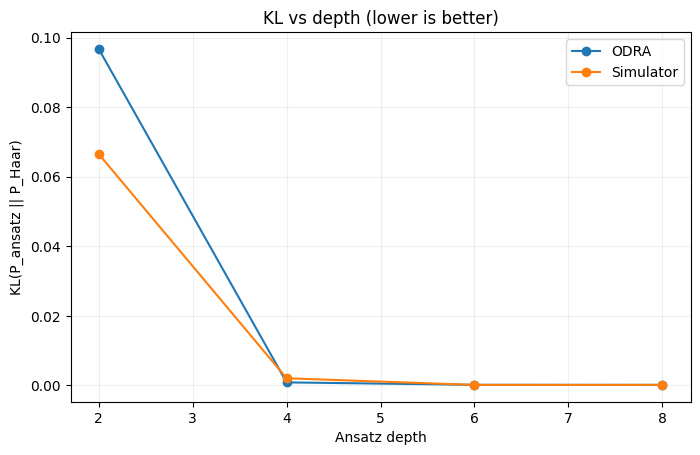

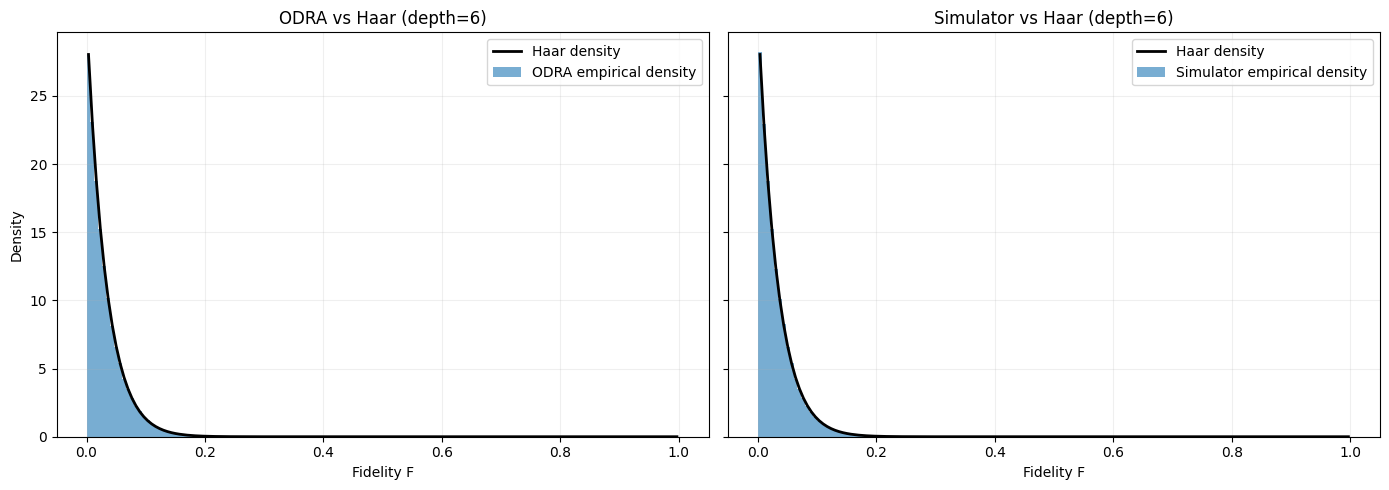

Interpretation: lower KL means a fidelity distribution closer to Haar.
Use the depth-vs-KL plot and table above to compare expressibility across depths.


In [14]:
depth_vals = np.array([row['depth'] for row in results])
kl_odra_vals = np.array([row['kl_odra'] for row in results])
kl_sim_vals = np.array([row['kl_simulator'] for row in results])

plt.figure(figsize=(8, 4.8))
plt.plot(depth_vals, kl_odra_vals, marker='o', label='ODRA')
plt.plot(depth_vals, kl_sim_vals, marker='o', label='Simulator')
plt.xlabel('Ansatz depth')
plt.ylabel('KL(P_ansatz || P_Haar)')
plt.title('KL vs depth (lower is better)')
plt.grid(alpha=0.2)
plt.legend()
plt.show()

best_depth = DEPTH_FOR_CONVERGENCE
plot_data = depth_distributions[best_depth]

mids = plot_data['mids']
edges = plot_data['edges']
p_odra = plot_data['p_odra']
p_sim = plot_data['p_sim']
bin_width = edges[1] - edges[0]
haar_curve = haar_pdf_fidelity(mids, DIM)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].bar(mids, p_odra / bin_width, width=bin_width, alpha=0.6, label='ODRA empirical density')
axes[0].plot(mids, haar_curve, color='black', lw=2, label='Haar density')
axes[0].set_title(f'ODRA vs Haar (depth={best_depth})')
axes[0].set_xlabel('Fidelity F')
axes[0].set_ylabel('Density')
axes[0].grid(alpha=0.2)
axes[0].legend()

axes[1].bar(mids, p_sim / bin_width, width=bin_width, alpha=0.6, label='Simulator empirical density')
axes[1].plot(mids, haar_curve, color='black', lw=2, label='Haar density')
axes[1].set_title(f'Simulator vs Haar (depth={best_depth})')
axes[1].set_xlabel('Fidelity F')
axes[1].grid(alpha=0.2)
axes[1].legend()

plt.tight_layout()
plt.show()

print('Interpretation: lower KL means a fidelity distribution closer to Haar.')
print('Use the depth-vs-KL plot and table above to compare expressibility across depths.')

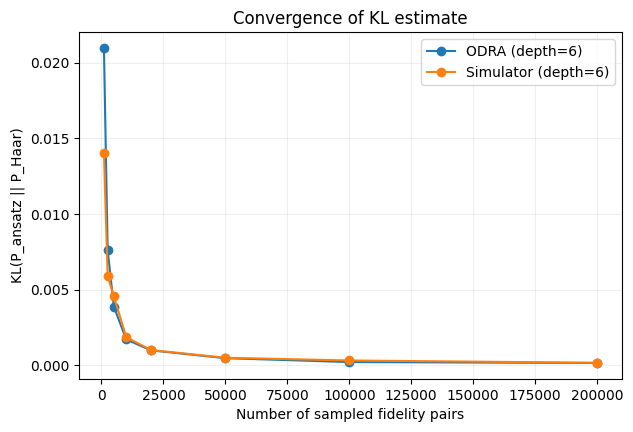

In [15]:
def kl_convergence(circuit: QuantumCircuit, sample_sizes, dim: int, n_bins: int, eps: float, seed: int):
    out = []
    for s in tqdm_maybe(sample_sizes, desc='Convergence sweep', total=len(sample_sizes)):
        local_rng = np.random.default_rng(seed + int(s))
        fids = sample_fidelities(
            circuit,
            int(s),
            local_rng,
            show_progress=False,
            progress_desc=f'Convergence samples={int(s)}',
        )
        _, _, p_emp, p_haar_ref = binned_distributions(fids, dim, n_bins)
        out.append(kl_divergence(p_emp, p_haar_ref, eps))
    return np.array(out)


sizes = np.unique(
    np.concatenate(
        [np.array([1000, 2500, 5000, 10000, 20000, 50000, 100_000]), np.array([N_FIDELITY_SAMPLES_PER_DEPTH])]
    )
)
odra_qc_conv = odra_ansatz(N_QUBITS, DEPTH_FOR_CONVERGENCE)
sim_qc_conv = simulator_ansatz(N_QUBITS, DEPTH_FOR_CONVERGENCE)

kl_track_odra = kl_convergence(odra_qc_conv, sizes, DIM, N_BINS, EPS, seed=SEED)
kl_track_sim = kl_convergence(sim_qc_conv, sizes, DIM, N_BINS, EPS, seed=SEED + 1)

plt.figure(figsize=(7, 4.5))
plt.plot(sizes, kl_track_odra, marker='o', label=f'ODRA (depth={DEPTH_FOR_CONVERGENCE})')
plt.plot(sizes, kl_track_sim, marker='o', label=f'Simulator (depth={DEPTH_FOR_CONVERGENCE})')
plt.xlabel('Number of sampled fidelity pairs')
plt.ylabel('KL(P_ansatz || P_Haar)')
plt.title('Convergence of KL estimate')
plt.grid(alpha=0.2)
plt.legend()
plt.show()

## Optional appendix: checkpoint shape sanity check

Te checkpointy nie sa uzywane do glownej metryki expressibility (standard protocol losuje parametry),
ale mozna sprawdzic zgodnosc rozmiaru parametrow.

In [ ]:
def flatten_numel_from_checkpoint(path: Path) -> int:
    obj = torch.load(path, map_location='cpu')
    if isinstance(obj, dict):
        if all(hasattr(v, 'numel') for v in obj.values()):
            return int(sum(v.numel() for v in obj.values()))
        if 'state_dict' in obj and isinstance(obj['state_dict'], dict):
            return int(sum(v.numel() for v in obj['state_dict'].values() if hasattr(v, 'numel')))
    raise ValueError(f'Unsupported checkpoint format: {path}')


base = Path('tests/divergence')
odra_ckpt = base / 'ansatz_odra_2_weights.pth'
sim_ckpt = base / 'ansatz_simulator_2_weights.pth'

odra_qc_depth2 = odra_ansatz(N_QUBITS, 2)
sim_qc_depth2 = simulator_ansatz(N_QUBITS, 2)
expected_odra = len(odra_qc_depth2.parameters)
expected_sim = len(sim_qc_depth2.parameters)

print('Expected trainable params (depth=2, matching checkpoint naming):')
print(f'  ODRA ansatz      : {expected_odra}')
print(f'  Simulator ansatz : {expected_sim}')

if odra_ckpt.exists() and sim_ckpt.exists():
    odra_numel = flatten_numel_from_checkpoint(odra_ckpt)
    sim_numel = flatten_numel_from_checkpoint(sim_ckpt)
    print('\nCheckpoint flattened numel (all tensors in file):')
    print(f'  {odra_ckpt.name}: {odra_numel}')
    print(f'  {sim_ckpt.name}: {sim_numel}')
    print('\nNote: if checkpoint stores full model state_dict, numel can exceed ansatz-only parameter count.')
else:
    print('Checkpoint files not found in tests/divergence.')